In [4]:
# Install the package if necessary, package repo: https://github.com/pvigier/perlin-numpy
# !pip3 install git+https://github.com/pvigier/perlin-numpy

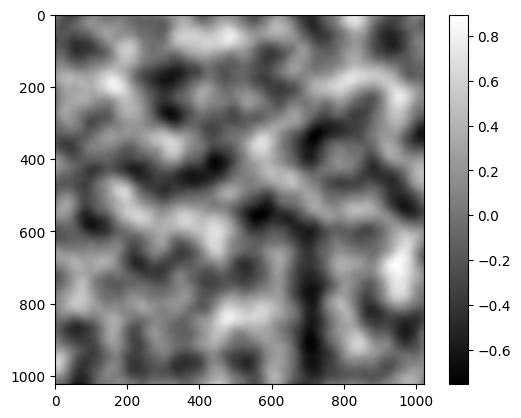

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from perlin_numpy import (
    generate_perlin_noise_2d, generate_fractal_noise_2d
)

#np.random.seed(0)
#noise = generate_perlin_noise_2d((256, 256), (8, 8))
#plt.imshow(noise, cmap='gray', interpolation='lanczos')
#plt.colorbar()

#np.random.seed(0)
noise = generate_fractal_noise_2d((1024, 1024), (8, 8), 
                                  octaves=8,
                                 persistence=0.2,
                                 lacunarity=2,
                                 #tileable=(True,True)
                                 )
plt.figure()
plt.imshow(noise, cmap='gray', interpolation='lanczos')
plt.colorbar()
plt.show()

In [11]:
def generate_noise(x, y):
    noise = generate_fractal_noise_2d((1024, 1024), (8, 8), 
                                  octaves=8,
                                 persistence=0.2,
                                 lacunarity=2,
                                 #tileable=(True,True)
                                 )
    res = []
    for i in range(y):
        res.append([])
        for j in range(x):
            closest_x = math.floor((i/x)*1024)
            closest_y = math.floor((j/y)*1024)
            res[i].append(noise[closest_x][closest_y])
    #plt.figure()
    #plt.imshow(res, cmap='gray', interpolation='lanczos')
    #plt.colorbar()
    #plt.show()
    return res


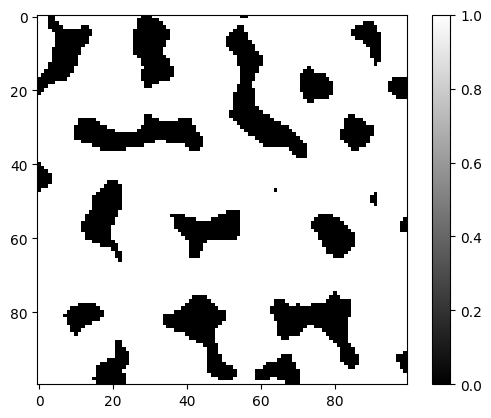

In [12]:
width = 100
height = 100
risk_density = 0.65
width_height_kilometers = 100
cell_distance = width_height_kilometers/width

risk_threshold = ((1-risk_density)*2)-1

risk_map = generate_noise(width, height)
for i in range(width):
    for j in range(height):
        if risk_map[i][j] > risk_threshold:
            risk_map[i][j] = 1
        else:
            risk_map[i][j] = 0
plt.figure()
plt.imshow(risk_map, cmap='gray')
plt.colorbar()
plt.show()

height_map = generate_noise(width, height)
forest_rate = generate_noise(width, height)
fire_spread_rate = generate_noise(width, height)
is_village = generate_noise(width, height)
vision_bonuses = [[0 for _ in range(width)] for _ in range(height)]
is_buildable_map = [[True for _ in range(width)] for _ in range(height)]
for i in range(width):
    for j in range(height):
        node_height = (1+height_map[i][j])*150
        vision_bonuses[i][j] = int(20*height_map[i][j])
        height_map[i][j] = node_height
        fire_spread_rate[i][j] += 1
        fire_spread_rate[i][j] /= 2
        fire_spread_rate[i][j] += 1
        forest_rate[i][j] += 1
        forest_rate[i][j] /= 2
        forest_rate[i][j] *= 0.8
        forest_rate[i][j] += 0.2
        if is_village[i][j] > 0.7:
            is_village[i][j] = 1
        else:
            is_village[i][j] = 0
        

In [13]:
lines = []
for i in range(width):
    for j in range(height):
        id = 1 + (i*width) + j
        x_coord = (i/width) * width_height_kilometers
        y_coord = (j/height) * width_height_kilometers
        node_height = int(height_map[i][j])
        risk_status = 'risky' if (risk_map[i][j] == 1) else 'not_risky'
        is_buildable = 'buildable' if is_buildable_map[i][j] else 'not_buildable'
        vision_bonus = vision_bonuses[i][j]
        #print(f"""{id} {x_coord:.2f} {y_coord:.2f} {node_height}m {risk_status} {is_buildable} {vision_bonus}%""")
        lines.append([id, x_coord, y_coord, node_height, risk_status, is_buildable, f'{vision_bonus}%', forest_rate[i][j], fire_spread_rate[i][j], is_village[i][j]])
df1 = pd.DataFrame(lines, columns = ['id', 'x_coord', 'y_coord', 'height', 'risk_status', 'is_buildable', 'vision_bonus', 'forest_rate', 'fire_spread_rate', 'is_village'])
df1

,id,x_coord,y_coord,height,risk_status,is_buildable,vision_bonus,forest_rate,fire_spread_rate,is_village
0,1,0.0,0.0,150,risky,buildable,0%,0.600000,1.500000,0
1,2,0.0,1.0,128,risky,buildable,-2%,0.614207,1.496228,0
2,3,0.0,2.0,111,risky,buildable,-5%,0.604458,1.485683,0
3,4,0.0,3.0,101,not_risky,buildable,-6%,0.579243,1.482052,0
4,5,0.0,4.0,94,not_risky,buildable,-7%,0.550180,1.490857,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,99.0,95.0,189,risky,buildable,5%,0.705878,1.524098,0
9996,9997,99.0,96.0,187,risky,buildable,4%,0.686110,1.479115,0
9997,9998,99.0,97.0,180,risky,buildable,4%,0.666556,1.442355,0
9998,9999,99.0,98.0,166,risky,buildable,2%,0.643806,1.418081,0


In [14]:
lines = []
lines.append(['UAV_type_A', 5, 5, 100, 5, 6])
lines.append(['UAV_type_B', 10, 3, 100, 5, 6])
lines.append(['Surv_Tower_Basic', 12, 0, 100, 5, 6])
lines.append(['Augmented_Tower', 12, 0, 100, 5, 6])
df2 = pd.DataFrame(lines, columns = ['observer_type', 'vision_radius', 'inventory', 'cost', 'min_vision', 'max_vision'])
df2

,observer_type,vision_radius,inventory,cost,min_vision,max_vision
0,UAV_type_A,5,5,100,5,6
1,UAV_type_B,10,3,100,5,6
2,Surv_Tower_Basic,12,0,100,5,6
3,Augmented_Tower,12,0,100,5,6


In [15]:
def is_covering(source_xy, target_xy, vision_minmax):
    source_x, source_y = source_xy
    target_x, target_y = target_xy
    vision_min, vision_max = vision_minmax
    dist = cell_distance * ((source_x-target_x)**2 + (source_y-target_y)**2)**(1/2)
    
    vision_min *= 1 + (vision_bonuses[source_x][source_y] * 0.01)
    vision_max *= 1 + (vision_bonuses[source_x][source_y] * 0.01)
    print(f'Distance: {dist}')
    if dist < vision_min:
        return 1
    if dist > vision_max:
        return 0
    return (dist-vision_min)/(vision_max-vision_min)
is_covering(source_xy= (11, 11), 
            target_xy= (13, 13), 
            vision_minmax=(3, 4))

Distance: 2.8284271247461903


1

In [16]:
with pd.ExcelWriter('problem_data.xlsx') as writer:
    df1.to_excel(writer, sheet_name="Nodes", index=False)
    df2.to_excel(writer, sheet_name="Parameters", index=False)

In [16]:
def draw_heatmap(freq_map, boolean_map, start_color, end_color, alt_start_color, alt_end_color):
    width, height = len(freq_map), len(freq_map[0])
    color_array = [[ (0, 0, 0) for _ in range(width)] for _ in range(height)]
    for i in range(width):
        for j in range(height):
            if boolean_map[i][j] > 0.5:
                r_diff = (end_color[0]-start_color[0])
                g_diff = (end_color[1]-start_color[1])
                b_diff = (end_color[2]-start_color[2])
                r_gain = r_diff * freq_map[i][j]
                g_gain = g_diff * freq_map[i][j]
                b_gain = b_diff * freq_map[i][j]
                color = (start_color[0] + r_gain, start_color[1] + g_gain, start_color[2] + b_gain)
                color_array[i][j] = color
            else:
                r_diff = (alt_end_color[0]-alt_start_color[0])
                g_diff = (alt_end_color[1]-alt_start_color[1])
                b_diff = (alt_end_color[2]-alt_start_color[2])
                r_gain = r_diff * freq_map[i][j]
                g_gain = g_diff * freq_map[i][j]
                b_gain = b_diff * freq_map[i][j]
                color = (alt_start_color[0] + r_gain, alt_start_color[1] + g_gain, alt_start_color[2] + b_gain)
                color_array[i][j] = color
    plt.figure()
    plt.imshow(color_array)
    plt.show()

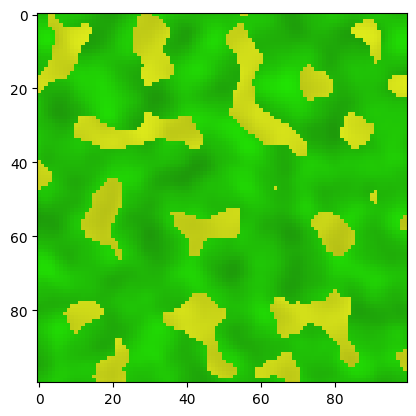

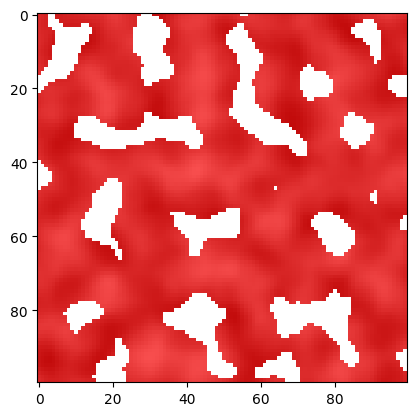

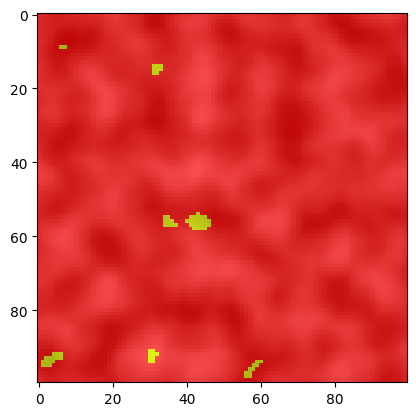

In [17]:
dark_green = (0.118, 0.561, 0.047)
light_green = (0.133, 1, 0)

dark_yellow = (0.635, 0.671, 0.075)
light_yellow = (0.91, 0.961, 0.11)

dark_red = (0.729, 0, 0)
light_red = (0.99, 0.329, 0.329)

dark_blue = (0, 0.094, 0.561)
light_blue = (0.502, 0.588, 1)

white = (1.0, 1.0, 1.0)

draw_heatmap(forest_rate, risk_map, light_green, dark_green, dark_yellow, light_yellow)
fire_freq = [[fire_spread_rate[i][j]-1 for i in range(width)] for j in range(height)]
draw_heatmap(fire_freq, risk_map, dark_red, light_red, white, white)
draw_heatmap(fire_freq, is_village, dark_yellow, light_yellow, dark_red, light_red)



In [30]:
import heapq
from heapq import heappush, heappop
def calculate_burn_value(px, py, spread_time, value_map, response_time = 10):
    # spread map means how long the node takes to spread
    # lots of simplifications but with enough precision they should vanish
    # however, it seems that our fire will spread circularly rather than elliptically
    # because we dont use the fire spread origin info
    width = len(spread_time)
    height = len(spread_time[0])
    pq = []
    heappush(pq, (0, px, py))
    forests_burned = []
    is_visited = [[False for _ in range(width)] for _ in range(height)]
    # bfs time
    while len(pq):
        fire_start_time, x, y = heappop(pq)
        if is_visited[x][y]:
            continue
        is_visited[x][y] = True
        if fire_start_time + spread_time[x][y] > response_time:
            burnt_time = response_time - fire_start_time
            forests_burned.append(value_map[x][y]*(burnt_time/spread_time[x][y]))
            continue
        forests_burned.append(value_map[x][y])
        cur_spread_time = fire_start_time + spread_time[x][y]
        if x > 0:
            heappush(pq, (cur_spread_time, x-1, y))
        if y > 0:
            heappush(pq, (cur_spread_time, x, y-1))
        if x+1 < width:
            heappush(pq, (cur_spread_time, x+1, y))
        if y+1 < height:
            heappush(pq, (cur_spread_time, x, y+1))
        return sum(forests_burned)/len(forests_burned)

# seems to work but some validation required
calculate_burn_value(50, 55, fire_spread_rate, forest_rate)

np.float64(0.5101282146573369)